In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\hercd\AppData\Local\Temp\ipykernel_10540\2660915427.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
file_paths = ["D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kWh_2012.csv",
              "D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kWh_2013.csv",
              "D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kWh_2014.csv", 
              "D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kWh_2015.csv",
              "D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kWh_2016.csv",
              "D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kWh_2020.csv",
              "D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kWh_2021.csv",
              "D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kWh_2022.csv",
              "D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kwh_2023.csv",
              "D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\kwh_per_year\kwh_2024.csv"]

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D

In [3]:
dataframes = []

for file_path in file_paths:
    df = pd.read_csv(file_path, delimiter=',')
    
    df[['Date', 'Kwh']] = df['Time'].str.split(',', expand=True)
    
    df = df[['Date', 'Kwh']]
    
    dataframes.append(df)

combined_df = pd.concat(dataframes, ignore_index=True)

combined_df.set_index('Date', inplace=True)

print(combined_df.head())

                       Kwh
Date                      
23/02/2012 07:00  "0.0063"
23/02/2012 08:00  "0.1181"
23/02/2012 09:00  "0.3531"
23/02/2012 10:00   "0.445"
23/02/2012 11:00  "0.6291"


In [4]:
combined_df['Kwh'] = combined_df['Kwh'].str.replace('\"', '', regex=False)

In [5]:
combined_df.index = pd.to_datetime(combined_df.index, format='%d/%m/%Y %H:%M' )
combined_df['Kwh'] = pd.to_numeric(combined_df["Kwh"])

In [6]:
df_past = combined_df[combined_df.index < "2020-01-01 00:00:00"]
df_new = combined_df[combined_df.index >= "2020-01-01 00:00:00"]

In [7]:
df_past, df_new

(                        Kwh
 Date                       
 2012-02-23 07:00:00  0.0063
 2012-02-23 08:00:00  0.1181
 2012-02-23 09:00:00  0.3531
 2012-02-23 10:00:00  0.4450
 2012-02-23 11:00:00  0.6291
 ...                     ...
 2016-12-30 13:00:00  0.3201
 2016-12-30 14:00:00  0.3092
 2016-12-30 15:00:00  0.1746
 2016-12-30 16:00:00  0.0659
 2016-12-30 17:00:00  0.0004
 
 [23732 rows x 1 columns],
                         Kwh
 Date                       
 2020-01-01 08:00:00  0.0513
 2020-01-01 09:00:00  0.2104
 2020-01-01 10:00:00  0.3981
 2020-01-01 11:00:00  0.5015
 2020-01-01 12:00:00  0.5235
 ...                     ...
 2024-07-04 19:00:00  0.0592
 2024-07-04 20:00:00  0.0085
 2024-07-04 21:00:00  0.0000
 2024-07-04 22:00:00  0.0000
 2024-07-04 23:00:00  0.0000
 
 [34757 rows x 1 columns])

In [8]:
full_index_past = pd.date_range(start=df_past.index.min(), end=df_past.index.max(), freq="H")
full_index_new = pd.date_range(start= df_new.index.min(), end = df_new.index.max(), freq= "H")


C:\Users\hercd\AppData\Local\Temp\ipykernel_10540\1447887043.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index_past = pd.date_range(start=df_past.index.min(), end=df_past.index.max(), freq="H")
C:\Users\hercd\AppData\Local\Temp\ipykernel_10540\1447887043.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index_new = pd.date_range(start= df_new.index.min(), end = df_new.index.max(), freq= "H")


In [9]:
df_past = df_past.reindex(full_index_past, fill_value=0)
df_new = df_new.reindex(full_index_new, fill_value= 0)
df_past, df_new

(                        Kwh
 2012-02-23 07:00:00  0.0063
 2012-02-23 08:00:00  0.1181
 2012-02-23 09:00:00  0.3531
 2012-02-23 10:00:00  0.4450
 2012-02-23 11:00:00  0.6291
 ...                     ...
 2016-12-30 13:00:00  0.3201
 2016-12-30 14:00:00  0.3092
 2016-12-30 15:00:00  0.1746
 2016-12-30 16:00:00  0.0659
 2016-12-30 17:00:00  0.0004
 
 [42539 rows x 1 columns],
                         Kwh
 2020-01-01 08:00:00  0.0513
 2020-01-01 09:00:00  0.2104
 2020-01-01 10:00:00  0.3981
 2020-01-01 11:00:00  0.5015
 2020-01-01 12:00:00  0.5235
 ...                     ...
 2024-07-04 19:00:00  0.0592
 2024-07-04 20:00:00  0.0085
 2024-07-04 21:00:00  0.0000
 2024-07-04 22:00:00  0.0000
 2024-07-04 23:00:00  0.0000
 
 [39520 rows x 1 columns])

In [10]:
np.mean(df_past['Kwh']), np.mean(df_new['Kwh'])

(0.14745094619055457, 0.151356141194332)

In [11]:
np.var(df_past['Kwh']), np.var(df_new['Kwh'])

(0.04800325515525556, 0.05070378887574727)

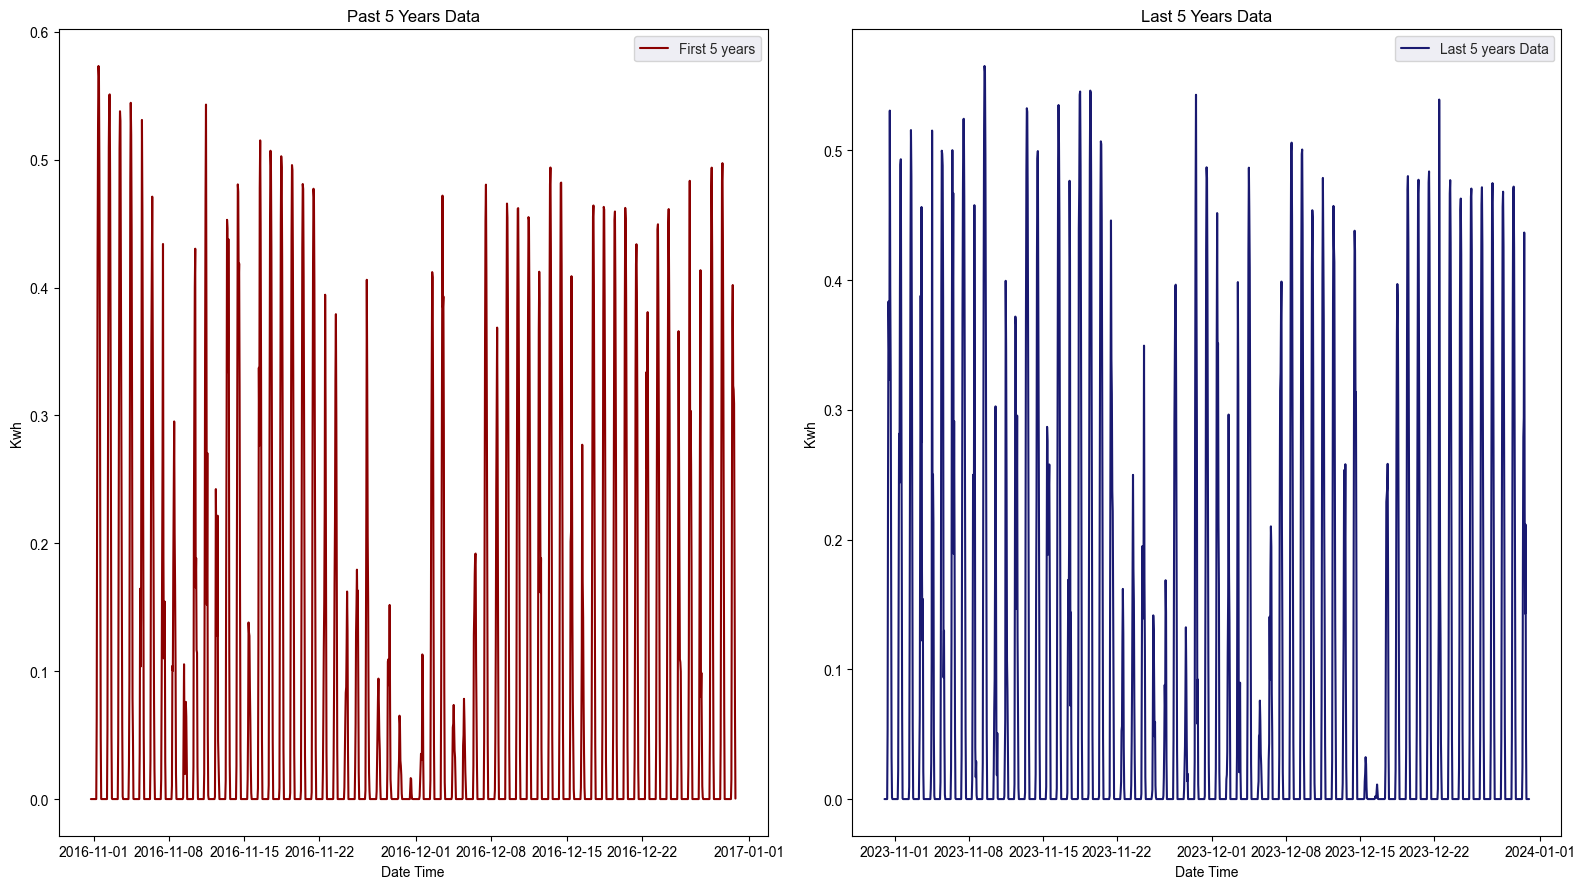

In [12]:
fig, axes = plt.subplots(nrows= 1, ncols= 2, figsize = (16, 9))
sns.set_style("darkgrid")
sns.lineplot(x = df_past.index[-1440:], y = df_past["Kwh"][-1440:], color = "DarkRed", label = "First 5 years", ax = axes[0])
axes[0].set_xlabel("Date Time")
axes[0].set_ylabel("Kwh")
axes[0].legend()
axes[0].set_title("Past 5 Years Data")

sns.lineplot(x = df_new.index[-5952 : -4488], y = df_new['Kwh'][-5952 : -4488], color = "MidnightBlue", label = "Last 5 years Data", ax = axes[1])
axes[1].set_xlabel("Date Time")
axes[1].set_ylabel("Kwh")
axes[1].legend()
axes[1].set_title("Last 5 Years Data")

plt.tight_layout()
plt.show()

In [13]:
df_past['Kwh'][-5952 : -4488][df_past['Kwh'][-5952 : -4488] != 0].mean(), df_new['Kwh'][-5952 : -4488][df_new['Kwh'][-5952 : -4488] != 0].mean()

(0.3293246102449889, 0.21103459552495696)

In [14]:
past_non_zero = df_past['Kwh'][df_past['Kwh'] != 0]
new_non_zero = df_new['Kwh'][df_new['Kwh'] != 0]

In [15]:
print(f"First 5 Yeas Non Null Values Mean = {round(past_non_zero.mean(), 5)} \nLast 5 Years Non Null Values Mean = {round(new_non_zero.mean(), 5)}")

First 5 Yeas Non Null Values Mean = 0.28901 
Last 5 Years Non Null Values Mean = 0.29995


In [16]:
df_past_grouped = df_past.groupby(df_past.index.hour).mean()
df_new_grouped = df_new.groupby(df_new.index.hour).mean()

In [17]:
pd.set_option('display.float_format', '{:.6f}'.format)

In [18]:
grouped_hours_df = pd.concat([df_past_grouped, 
                              df_new_grouped], axis=1)

grouped_hours_df.columns = ["First_5_Years_Mean", "Last_5_Years_Mean"]

grouped_hours_df

,First_5_Years_Mean,Last_5_Years_Mean
0,0.000000,0.000000
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000
4,0.000000,0.000000
5,0.000000,0.000000
6,0.002071,0.001479
7,0.045915,0.038927
8,0.159051,0.158113
9,0.293183,0.295672


In [19]:
grouped_hours_df["Past_Greater_New"] =grouped_hours_df['First_5_Years_Mean'] > grouped_hours_df['Last_5_Years_Mean']
grouped_hours_df

,First_5_Years_Mean,Last_5_Years_Mean,Past_Greater_New
0,0.000000,0.000000,False
1,0.000000,0.000000,False
2,0.000000,0.000000,False
3,0.000000,0.000000,False
4,0.000000,0.000000,False
5,0.000000,0.000000,False
6,0.002071,0.001479,True
7,0.045915,0.038927,True
8,0.159051,0.158113,True
9,0.293183,0.295672,False


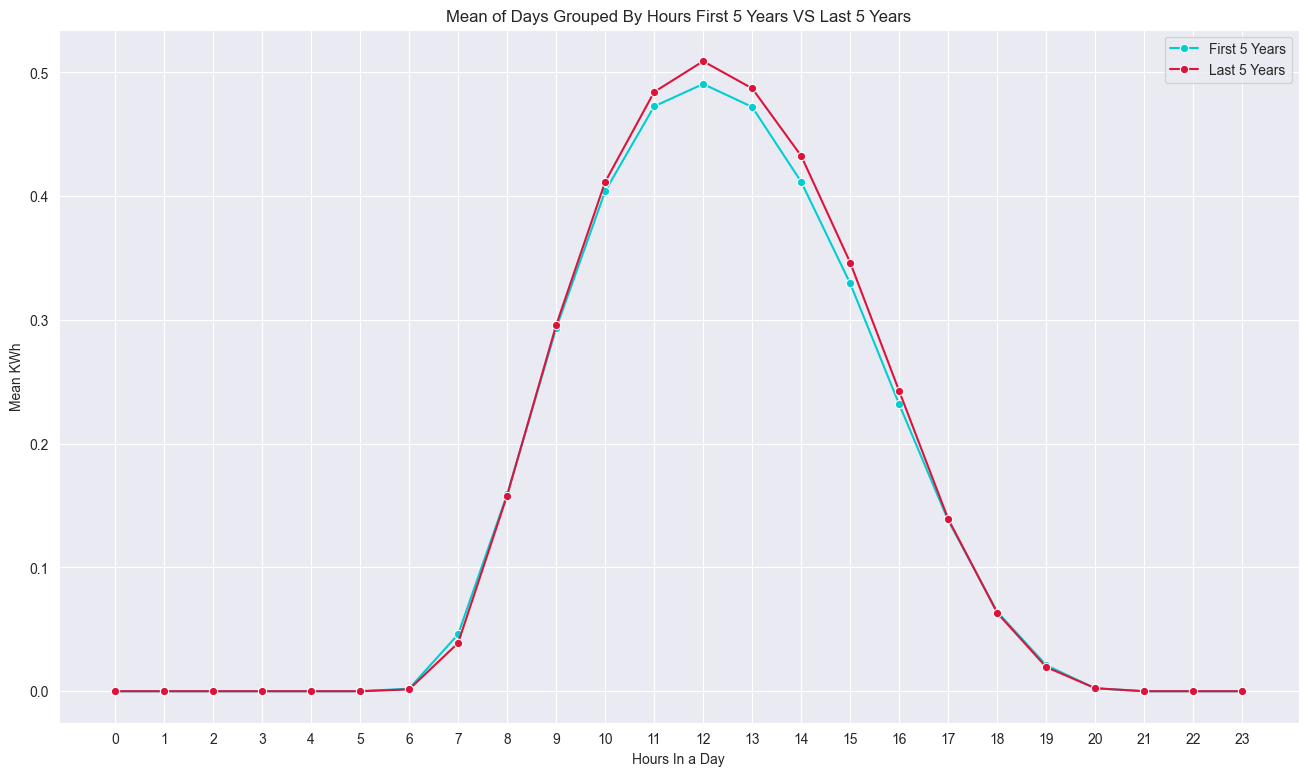

In [40]:
plt.figure(figsize= (16, 9))
sns.set_style('darkgrid')
sns.lineplot(x = grouped_hours_df.index, 
             y = grouped_hours_df['First_5_Years_Mean'],
             color = 'DarkTurquoise', marker= "o", label = "First 5 Years")
sns.lineplot(x = grouped_hours_df.index, 
             y = grouped_hours_df['Last_5_Years_Mean'],
             color = 'Crimson', marker= "o", label = "Last 5 Years")
plt.xlabel("Hours In a Day")
plt.ylabel("Mean KWh")
plt.title("Mean of Days Grouped By Hours First 5 Years VS Last 5 Years")
plt.xticks(np.arange(0, 24, 1))
plt.legend()
plt.show()

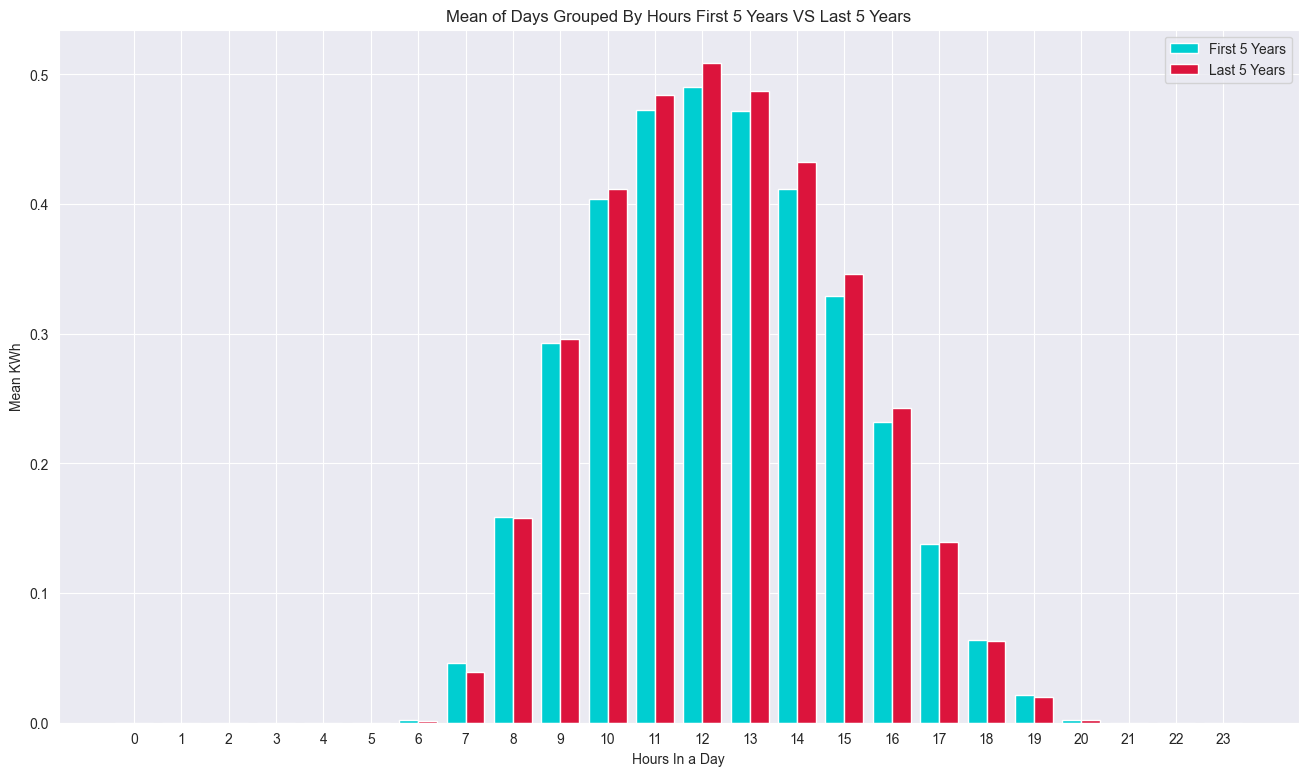

In [42]:
plt.figure(figsize=(16, 9))
sns.set_style('darkgrid')

bar_width = 0.4

x = grouped_hours_df.index

plt.bar(x - bar_width/2, grouped_hours_df['First_5_Years_Mean'], 
        width=bar_width, color='DarkTurquoise', label="First 5 Years")

plt.bar(x + bar_width/2, grouped_hours_df['Last_5_Years_Mean'], 
        width=bar_width, color='Crimson', label="Last 5 Years")

plt.xlabel("Hours In a Day")
plt.ylabel("Mean KWh")
plt.title("Mean of Days Grouped By Hours First 5 Years VS Last 5 Years")
plt.legend()
plt.xticks(np.arange(0, 24, 1))
plt.xticks(np.arange(0, 24, 1))

plt.show()


# Filtered Data Frame Summer

In [20]:
df_filtered_past_summer = df_past[(df_past.index.month >= 5) & (df_past.index.month <= 9)]

df_filtered_new_summer = df_new[(df_new.index.month >= 5) & (df_new.index.month <= 9)]

df_filtered_past_summer, df_filtered_new_summer

(                         Kwh
 2012-05-01 00:00:00 0.000000
 2012-05-01 01:00:00 0.000000
 2012-05-01 02:00:00 0.000000
 2012-05-01 03:00:00 0.000000
 2012-05-01 04:00:00 0.000000
 ...                      ...
 2016-09-30 19:00:00 0.000000
 2016-09-30 20:00:00 0.000000
 2016-09-30 21:00:00 0.000000
 2016-09-30 22:00:00 0.000000
 2016-09-30 23:00:00 0.000000
 
 [18360 rows x 1 columns],
                          Kwh
 2020-05-01 00:00:00 0.000000
 2020-05-01 01:00:00 0.000000
 2020-05-01 02:00:00 0.000000
 2020-05-01 03:00:00 0.000000
 2020-05-01 04:00:00 0.000000
 ...                      ...
 2024-07-04 19:00:00 0.059200
 2024-07-04 20:00:00 0.008500
 2024-07-04 21:00:00 0.000000
 2024-07-04 22:00:00 0.000000
 2024-07-04 23:00:00 0.000000
 
 [16248 rows x 1 columns])

In [21]:
df_filtered_past_summer_grouped = df_filtered_past_summer.groupby(df_filtered_past_summer.index.hour).mean()
df_filtered_new_summer_grouped = df_filtered_new_summer.groupby(df_filtered_new_summer.index.hour).mean()

In [22]:
grouped_hours_filtered_summer_df = pd.concat([df_filtered_past_summer_grouped, df_filtered_new_summer_grouped], axis=1)

grouped_hours_filtered_summer_df.columns = ["First_5_Years_Filtered_Mean", "Last_5_Years_Filtered_Mean"]

grouped_hours_filtered_summer_df

,First_5_Years_Filtered_Mean,Last_5_Years_Filtered_Mean
0,0.000000,0.000000
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000
4,0.000000,0.000000
5,0.000000,0.000000
6,0.004542,0.003428
7,0.082132,0.071292
8,0.230947,0.234095
9,0.383539,0.389053


In [23]:
grouped_hours_filtered_summer_df["Past_Greater_New"] = grouped_hours_filtered_summer_df['First_5_Years_Filtered_Mean'] > grouped_hours_filtered_summer_df['Last_5_Years_Filtered_Mean']
grouped_hours_filtered_summer_df

,First_5_Years_Filtered_Mean,Last_5_Years_Filtered_Mean,Past_Greater_New
0,0.000000,0.000000,False
1,0.000000,0.000000,False
2,0.000000,0.000000,False
3,0.000000,0.000000,False
4,0.000000,0.000000,False
5,0.000000,0.000000,False
6,0.004542,0.003428,True
7,0.082132,0.071292,True
8,0.230947,0.234095,False
9,0.383539,0.389053,False


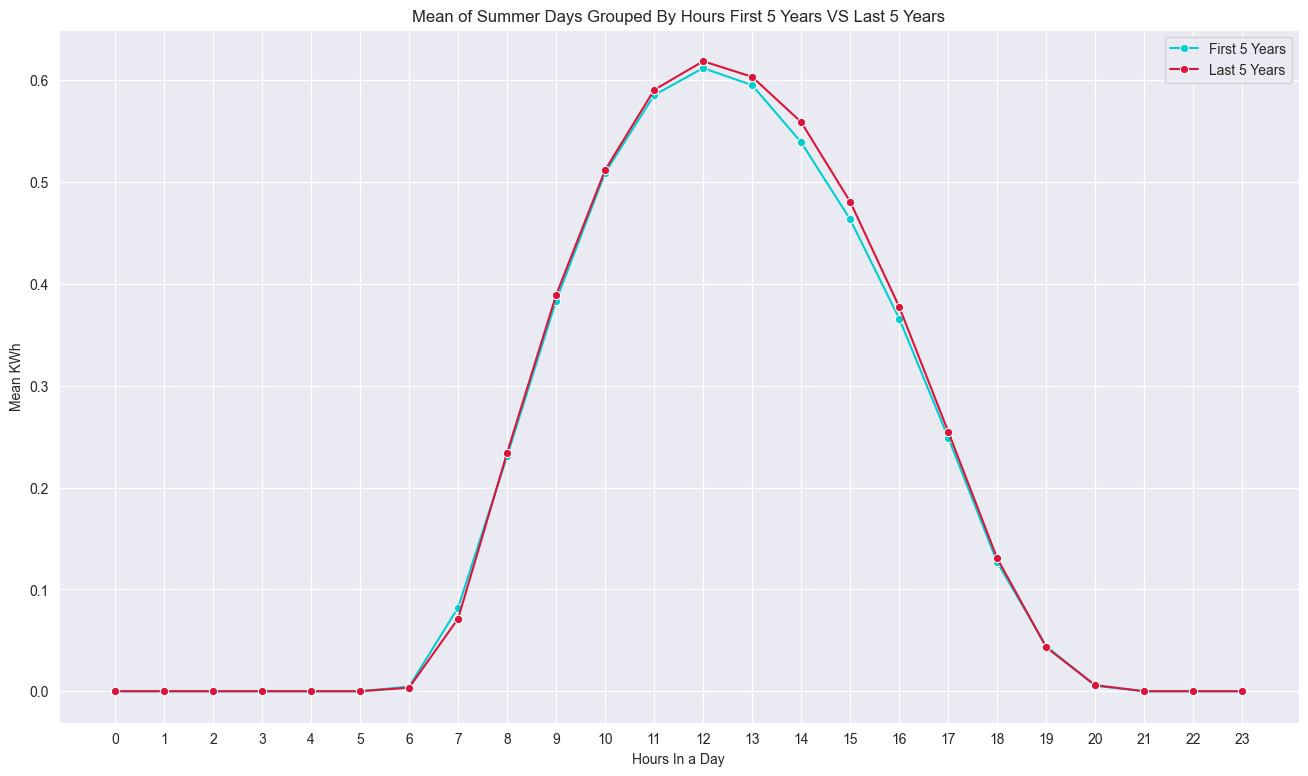

In [24]:
plt.figure(figsize= (16, 9))
sns.set_style('darkgrid')
sns.lineplot(x = grouped_hours_filtered_summer_df.index, 
             y = grouped_hours_filtered_summer_df['First_5_Years_Filtered_Mean'],
             color = 'DarkTurquoise', marker= "o", label = "First 5 Years")
sns.lineplot(x = grouped_hours_filtered_summer_df.index, 
             y = grouped_hours_filtered_summer_df['Last_5_Years_Filtered_Mean'],
             color = 'Crimson', marker= "o", label = "Last 5 Years")
plt.xlabel("Hours In a Day")
plt.ylabel("Mean KWh")
plt.title("Mean of Summer Days Grouped By Hours First 5 Years VS Last 5 Years")
plt.xticks(np.arange(0, 24, 1))
plt.legend()
plt.show()

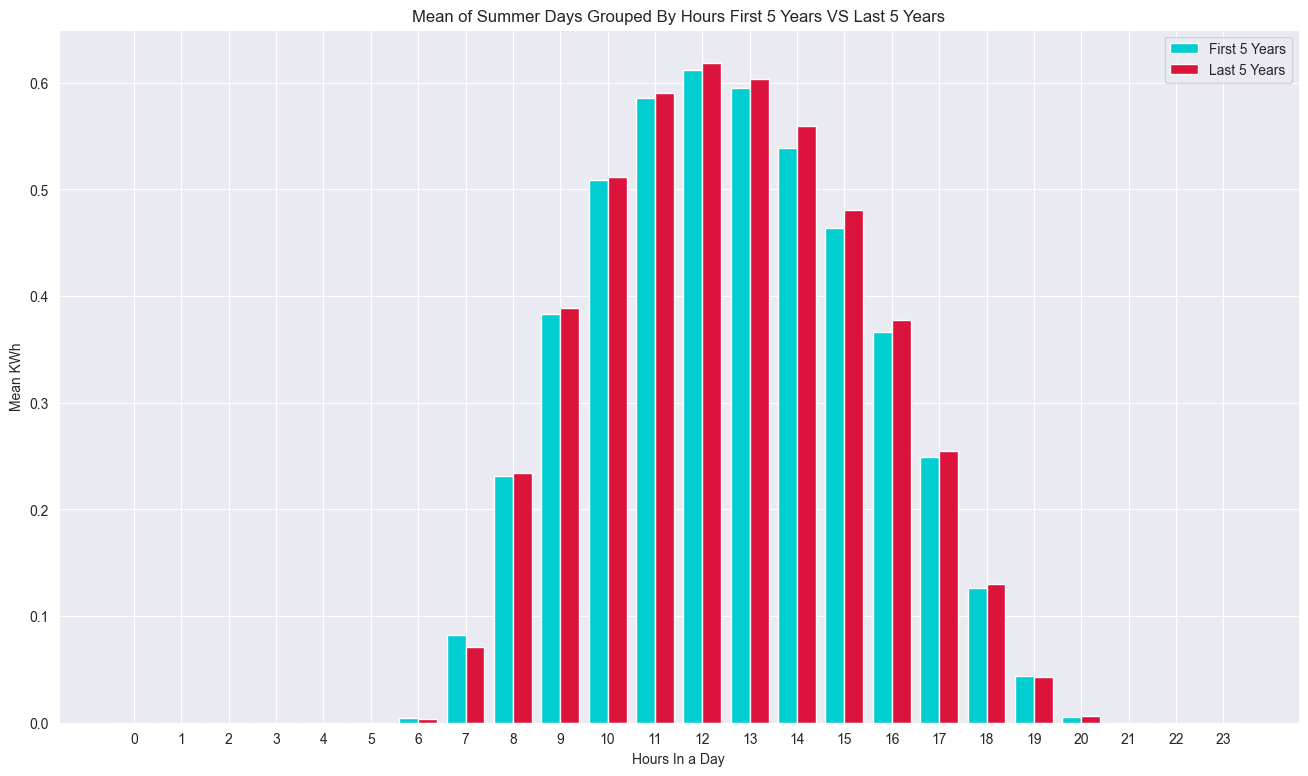

In [25]:
plt.figure(figsize=(16, 9))
sns.set_style('darkgrid')

bar_width = 0.4

x = grouped_hours_filtered_summer_df.index

plt.bar(x - bar_width/2, grouped_hours_filtered_summer_df['First_5_Years_Filtered_Mean'], 
        width=bar_width, color='DarkTurquoise', label="First 5 Years")

plt.bar(x + bar_width/2, grouped_hours_filtered_summer_df['Last_5_Years_Filtered_Mean'], 
        width=bar_width, color='Crimson', label="Last 5 Years")

plt.xlabel("Hours In a Day")
plt.ylabel("Mean KWh")
plt.title("Mean of Summer Days Grouped By Hours First 5 Years VS Last 5 Years")
plt.legend()
plt.xticks(np.arange(0, 24, 1))

plt.show()


# Filtered Data Frame Winter

In [35]:
df_filtered_past = df_past[(df_past.index.month >= 10) | (df_past.index.month <= 2)]

df_filtered_new = df_new[(df_new.index.month >= 10) | (df_new.index.month <= 2)]

df_filtered_past, df_filtered_new

(                         Kwh
 2012-02-23 07:00:00 0.006300
 2012-02-23 08:00:00 0.118100
 2012-02-23 09:00:00 0.353100
 2012-02-23 10:00:00 0.445000
 2012-02-23 11:00:00 0.629100
 ...                      ...
 2016-12-30 13:00:00 0.320100
 2016-12-30 14:00:00 0.309200
 2016-12-30 15:00:00 0.174600
 2016-12-30 16:00:00 0.065900
 2016-12-30 17:00:00 0.000400
 
 [16859 rows x 1 columns],
                          Kwh
 2020-01-01 08:00:00 0.051300
 2020-01-01 09:00:00 0.210400
 2020-01-01 10:00:00 0.398100
 2020-01-01 11:00:00 0.501500
 2020-01-01 12:00:00 0.523500
 ...                      ...
 2024-02-29 19:00:00 0.000000
 2024-02-29 20:00:00 0.000000
 2024-02-29 21:00:00 0.000000
 2024-02-29 22:00:00 0.000000
 2024-02-29 23:00:00 0.000000
 
 [15952 rows x 1 columns])

In [34]:
df_filtered_past_grouped = df_filtered_past.groupby(df_filtered_past.index.hour).mean()
df_filtered_new_grouped = df_filtered_new.groupby(df_filtered_new.index.hour).mean()

In [36]:
grouped_hours_filtered_winter_df = pd.concat([df_filtered_past_grouped, df_filtered_new_grouped], axis=1)

grouped_hours_filtered_winter_df.columns = ["First_5_Years_Filtered_Mean", "Last_5_Years_Filtered_Mean"]

grouped_hours_filtered_winter_df

,First_5_Years_Filtered_Mean,Last_5_Years_Filtered_Mean
0,0.000000,0.000000
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000
4,0.000000,0.000000
5,0.000000,0.000000
6,0.000000,0.000000
7,0.005275,0.003272
8,0.070987,0.067886
9,0.184871,0.188137


In [37]:
grouped_hours_filtered_winter_df["Past_Greater_New"] = grouped_hours_filtered_winter_df['First_5_Years_Filtered_Mean'] > grouped_hours_filtered_winter_df['Last_5_Years_Filtered_Mean']
grouped_hours_filtered_winter_df

,First_5_Years_Filtered_Mean,Last_5_Years_Filtered_Mean,Past_Greater_New
0,0.000000,0.000000,False
1,0.000000,0.000000,False
2,0.000000,0.000000,False
3,0.000000,0.000000,False
4,0.000000,0.000000,False
5,0.000000,0.000000,False
6,0.000000,0.000000,False
7,0.005275,0.003272,True
8,0.070987,0.067886,True
9,0.184871,0.188137,False


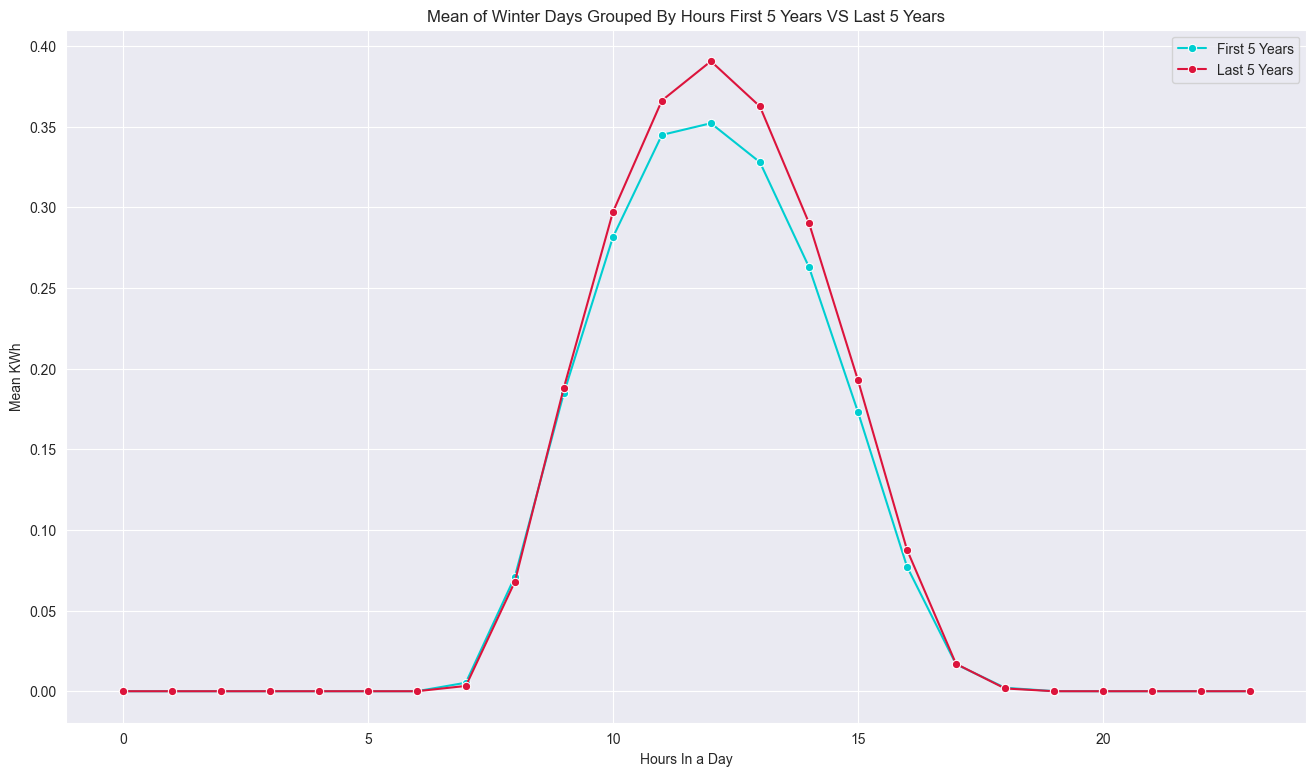

In [38]:
plt.figure(figsize= (16, 9))
sns.set_style('darkgrid')
sns.lineplot(x = grouped_hours_filtered_winter_df.index, 
             y = grouped_hours_filtered_winter_df['First_5_Years_Filtered_Mean'],
             color = 'DarkTurquoise', marker= "o", label = "First 5 Years")
sns.lineplot(x = grouped_hours_filtered_winter_df.index, 
             y = grouped_hours_filtered_winter_df['Last_5_Years_Filtered_Mean'],
             color = 'Crimson', marker= "o", label = "Last 5 Years")
plt.xlabel("Hours In a Day")
plt.ylabel("Mean KWh")
plt.title("Mean of Winter Days Grouped By Hours First 5 Years VS Last 5 Years")
plt.legend()
plt.show()

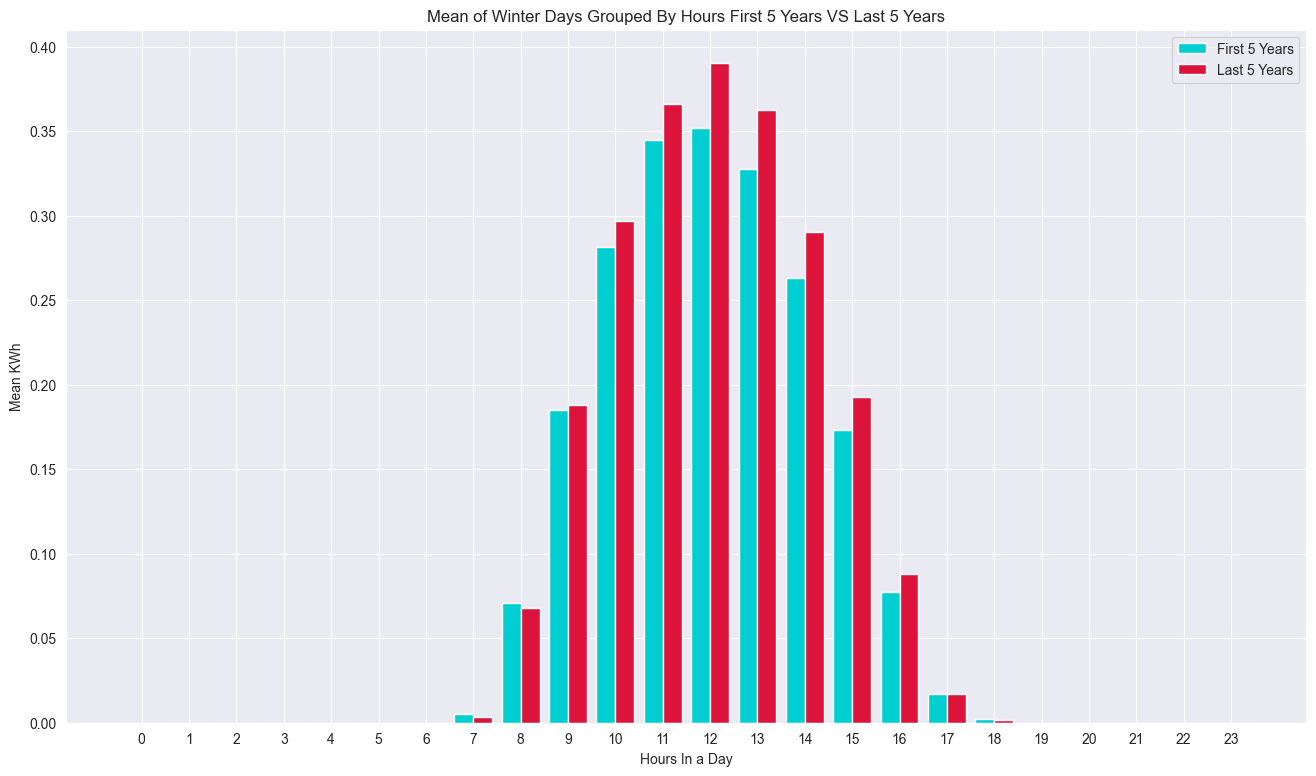

In [39]:
plt.figure(figsize=(16, 9))
sns.set_style('darkgrid')

bar_width = 0.4

x = grouped_hours_filtered_winter_df.index

plt.bar(x - bar_width/2, grouped_hours_filtered_winter_df['First_5_Years_Filtered_Mean'], 
        width=bar_width, color='DarkTurquoise', label="First 5 Years")

plt.bar(x + bar_width/2, grouped_hours_filtered_winter_df['Last_5_Years_Filtered_Mean'], 
        width=bar_width, color='Crimson', label="Last 5 Years")

plt.xlabel("Hours In a Day")
plt.ylabel("Mean KWh")
plt.title("Mean of Winter Days Grouped By Hours First 5 Years VS Last 5 Years")
plt.legend()
plt.xticks(np.arange(0, 24, 1))
plt.xticks(np.arange(0, 24, 1))

plt.show()
